<a href="https://colab.research.google.com/github/amitdey7/MS107/blob/master/2_tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tokenizer Example

In [ ]:
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
model_name = "HuggingFaceTB/SmolLM3-3B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [ ]:
prompt = "Recommend me places to see in bangalore"

model_inputs = tokenizer([prompt], return_tensors="pt")

print(model_inputs["input_ids"])

tensor([[68744,   757,  7634,   311,  1518,   304, 26518, 45021]])


In [ ]:
max_token_len = max(len(tokenizer.decode(tid)) for tid in model_inputs["input_ids"][0])
for tid in model_inputs["input_ids"][0]:
    print(f"{tokenizer.decode(tid):<{max_token_len}} -> {tid}")

Recommend -> 68744
 me       -> 757
 places   -> 7634
 to       -> 311
 see      -> 1518
 in       -> 304
 bang     -> 26518
alore     -> 45021


# Tokenization Techniques

Main reference : Build a Large Language Model (From Scratch) [Ch 2. Working with text data](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch02/)

## Word Level Tokenization

In [ ]:
import re

text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [ ]:
# get the corpus
import os
import requests

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

In [ ]:
raw_text = open("the-verdict.txt", "r", encoding="utf-8").read()
print(raw_text[:100])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g


In [ ]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [ ]:
total_tokens = len(preprocessed)
print(f"Total tokens: {total_tokens}")

Total tokens: 4690


In [ ]:
print(preprocessed[:100])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in', 'the', 'height', 'of', 'his', 'glory', ',', 'he', 'had', 'dropped', 'his', 'painting', ',', 'married', 'a', 'rich', 'widow', ',', 'and', 'established', 'himself', 'in', 'a', 'villa', 'on', 'the', 'Riviera', '.', '(', 'Though', 'I', 'rather', 'thought', 'it', 'would', 'have', 'been', 'Rome', 'or', 'Florence', '.', ')', '"', 'The', 'height', 'of', 'his', 'glory', '"', '--', 'that', 'was', 'what', 'the', 'women', 'called', 'it', '.', 'I', 'can', 'hear', 'Mrs', '.', 'Gideon', 'Thwing', '--', 'his', 'last', 'Chicago', 'sitter', '--']


## Converting tokens into token IDs

In [ ]:
# make a unique set of words
unique_tokens = sorted(set(preprocessed))
vocab_szie = len(unique_tokens)
print(f"Vocab size: {vocab_szie}")


Vocab size: 1130


In [ ]:
vocab = {word: idx for idx, word in enumerate(unique_tokens)}

In [ ]:
for token, idx in vocab.items():
    print(f"{token:10} -> {idx}")

    if idx >= 50:
        break

!          -> 0
"          -> 1
'          -> 2
(          -> 3
)          -> 4
,          -> 5
--         -> 6
.          -> 7
:          -> 8
;          -> 9
?          -> 10
A          -> 11
Ah         -> 12
Among      -> 13
And        -> 14
Are        -> 15
Arrt       -> 16
As         -> 17
At         -> 18
Be         -> 19
Begin      -> 20
Burlington -> 21
But        -> 22
By         -> 23
Carlo      -> 24
Chicago    -> 25
Claude     -> 26
Come       -> 27
Croft      -> 28
Destroyed  -> 29
Devonshire -> 30
Don        -> 31
Dubarry    -> 32
Emperors   -> 33
Florence   -> 34
For        -> 35
Gallery    -> 36
Gideon     -> 37
Gisburn    -> 38
Gisburns   -> 39
Grafton    -> 40
Greek      -> 41
Grindle    -> 42
Grindles   -> 43
HAD        -> 44
Had        -> 45
Hang       -> 46
Has        -> 47
He         -> 48
Her        -> 49
Hermia     -> 50


In [ ]:
token_ids = [vocab[token] for token in preprocessed]
print(token_ids[:30])

[53, 44, 149, 1003, 57, 38, 818, 115, 256, 486, 6, 1002, 115, 500, 435, 392, 6, 908, 585, 1077, 709, 508, 961, 1016, 663, 1016, 535, 987, 5, 568]


In [ ]:
# text to token IDs for a new text
text = "a genius thought"
token_ids = [vocab[token] for token in text.split()]
print(token_ids)


[115, 486, 1003]


In [ ]:
# token IDs to text
tid_mapping = {i:s for s,i in vocab.items()}
token_ids = [115, 486, 1003]

for token_id in token_ids:
  print(tid_mapping[token_id])

a
genius
thought


In [ ]:
# Tokenizer class for encoding and decoding
class SimpleTokenizerV1:
  def __init__(self, vocab):
    self.SPLIT_PATTERN = r'([,.:;?_!"()\']|--|\s)'
    self.vocab = vocab
    self.str_to_int = {s:i for s,i in vocab.items()}
    self.int_to_str = {i:s for s,i in vocab.items()}


  def encode(self, text):

    tokens = re.split(self.SPLIT_PATTERN, text)
    tokens = [item.strip() for item in tokens if item.strip()]
    token_ids = [self.str_to_int[token] for token in tokens]
    return token_ids

  def decode(self, token_ids):
    text = " ".join( [self.int_to_str[tid] for tid in token_ids])
    text = re.sub(self.SPLIT_PATTERN, r'\1', text)
    return text


In [ ]:
tokenizer = SimpleTokenizerV1(vocab)

text = """"It's the last he painted, you know,"
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)



[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [ ]:
tokenizer.decode(ids)

'" It \' s the last he painted , you know , " Mrs . Gisburn said with pardonable pride .'

In [ ]:
# encoding uknown text
text = "Transformers are the backbone of LLMs"
token_ids = tokenizer.encode(text)

KeyError: 'Transformers'

### Adding special tokens

- <|UNK|> for unknown tokens
- <|endoftext|> for seperating documents

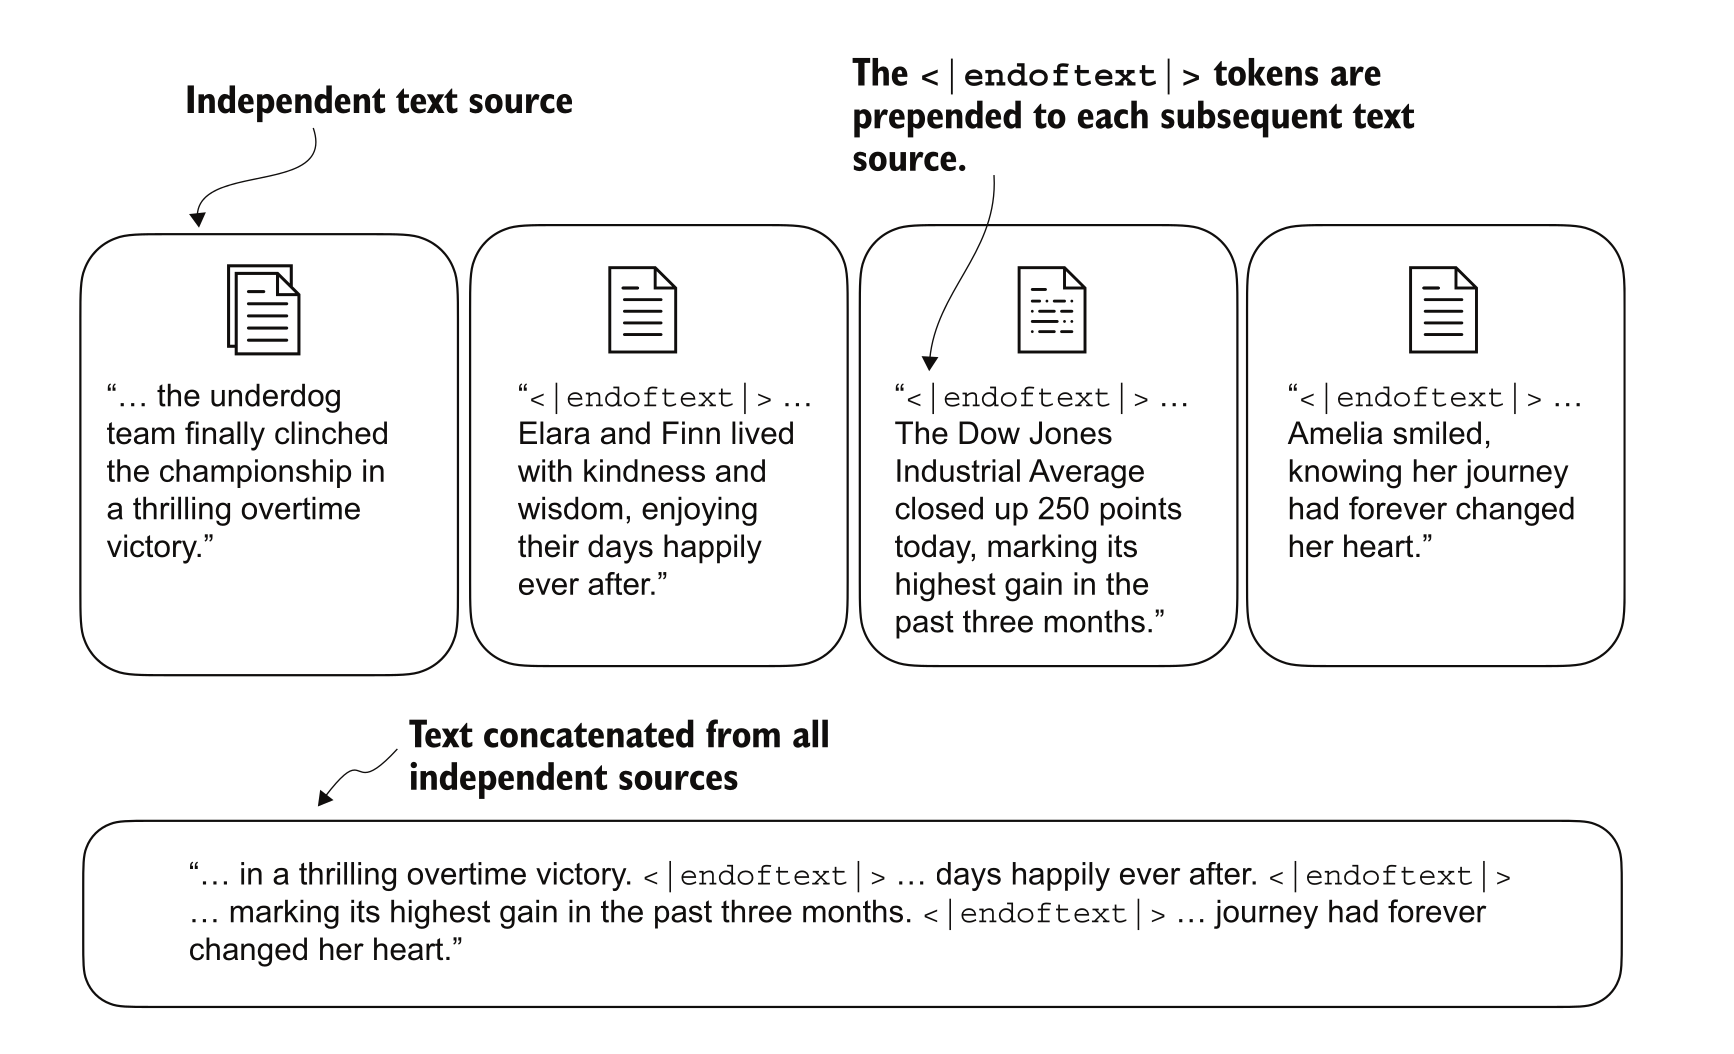

In [ ]:
special_tokens = ["<|unk|>", "<|endoftext|>"]

unique_tokens.extend(special_tokens)
vocab = {word: idx for idx, word in enumerate(unique_tokens)}

print(list(vocab.items())[-5:])

[('younger', 1127), ('your', 1128), ('yourself', 1129), ('<|unk|>', 1134), ('<|endoftext|>', 1135)]


In [ ]:
# Tokenizer class for encoding and decoding with special tokens
class SimpleTokenizerV2:
  def __init__(self, vocab):
    self.SPLIT_PATTERN = r'([,.:;?_!"()\']|--|\s)'
    self.vocab = vocab
    self.str_to_int = {s:i for s,i in vocab.items()}
    self.int_to_str = {i:s for s,i in vocab.items()}


  def encode(self, text):

    tokens = re.split(self.SPLIT_PATTERN, text)

    tokens = [item.strip() for item in tokens if item.strip()]
    tokens = [token if token in self.str_to_int else "<|unk|>" for token in tokens ]
    token_ids = [self.str_to_int[token] for token in tokens]
    return token_ids

  def decode(self, token_ids):
    text = " ".join( [self.int_to_str[tid] for tid in token_ids])
    text = re.sub(self.SPLIT_PATTERN, r'\1', text)
    return text

In [ ]:
tokenizer = SimpleTokenizerV2(vocab)

text = "Transformers are the backbone of LLMs"
token_ids = tokenizer.encode(text)
print(token_ids)
print(tokenizer.decode(token_ids))


[1134, 169, 988, 1134, 722, 1134]
<|unk|> are the <|unk|> of <|unk|>


## Character Level Tokenization

In [ ]:
class CharTokenizer:

  def __init__(self, vocab):
    self.vocab = {v:k for k, v in enumerate(vocab)}
    self.inv_vocab = {v: k for k, v in self.vocab.items()}
    print(self.vocab)

  def encode(self, text):
    return [self.vocab[c] for c in list(text)]


  def decode(self, ids):
    return ''.join(self.inv_vocab[i] for i in ids)

In [ ]:
vocab = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!. ")

tok = CharTokenizer(vocab)

ids = tok.encode("Transformer!!!!")
text = tok.decode(ids)
print(ids, len(ids))
print(text)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25, 'A': 26, 'B': 27, 'C': 28, 'D': 29, 'E': 30, 'F': 31, 'G': 32, 'H': 33, 'I': 34, 'J': 35, 'K': 36, 'L': 37, 'M': 38, 'N': 39, 'O': 40, 'P': 41, 'Q': 42, 'R': 43, 'S': 44, 'T': 45, 'U': 46, 'V': 47, 'W': 48, 'X': 49, 'Y': 50, 'Z': 51, '!': 52, '.': 53, ' ': 54}
[45, 17, 0, 13, 18, 5, 14, 17, 12, 4, 17, 52, 52, 52, 52] 15
Transformer!!!!


## Subword Tokenization



In [ ]:
import tiktoken

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

text = "Transformers are the backbone of LLMs"

token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

for i in token_ids:
  print(f"{tokenizer.decode([i]):10} : {i}")


Transform  : 41762
ers        : 364
 are       : 389
 the       : 262
 backbone  : 32774
 of        : 286
 LL        : 27140
Ms         : 10128
<|endoftext|> : 50256


In [ ]:
text = "supersacrafiligiouilacious"
token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(token_ids)
for i in token_ids:
  print(f"{tokenizer.decode([i]):10} : {i}")

[37330, 364, 330, 430, 10379, 25754, 280, 346, 14209]
sup        : 37330
ers        : 364
ac         : 330
ra         : 430
fil        : 10379
igi        : 25754
ou         : 280
il         : 346
acious     : 14209


In [ ]:
text1 = "Transformers are the backbone of LLMs"
text2 = "Tokenization prepares text for LLMs"

text = text1 + "<|endoftext|>" + text2

token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

for i in token_ids:
  print(f"{tokenizer.decode([i]):10} : {i}")

Transform  : 41762
ers        : 364
 are       : 389
 the       : 262
 backbone  : 32774
 of        : 286
 LL        : 27140
Ms         : 10128
<|endoftext|> : 50256
Token      : 30642
ization    : 1634
 prepares  : 25978
 text      : 2420
 for       : 329
 LL        : 27140
Ms         : 10128
